<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Metodos-computacionales/Tarea5_mc_jm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

## **1.** Numero medio de operaciones para resolver el sistema por eliminación Gaussiana:

$$A\overrightarrow{x}=\overrightarrow{b}$$

Siendo $A_{nn}$ matriz de tamaño $n$x$n$,


Numero de operaciones: [1.94166667e+02 1.46333333e+03 1.70316667e+05 1.34813333e+06]
Asociadas a cada n: [  5  10  50 100] 



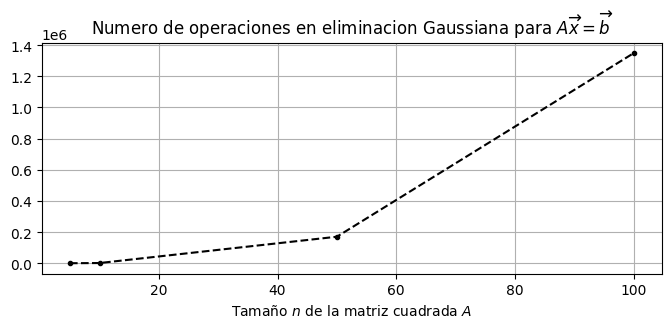

In [ ]:
M = lambda n: n**3 + n**2 - n/3        # numero de multiplicaciones
S = lambda n: n**3/3 + n**2/2 - 5*n/3  # numero de adiciones

n = np.array([5,10,50,100])
O = S(n) + M(n)

plt.figure(figsize=(8,3))
plt.title('Numero de operaciones en eliminacion Gaussiana para $A\overrightarrow{x}=\overrightarrow{b}$')
plt.xlabel('Tamaño $n$ de la matriz cuadrada $A$')
plt.plot(n,O, '.--', color='k')
plt.grid()
print('Numero de operaciones:', O)
print('Asociadas a cada n:', n,'\n')

####**Discusión:**
<p align="justify"> Se observa que el número de operaciones necesarias para efectuar la reducción Gaussiana a una matriz cuadrada $A$ de tamaño $n$x$n$, crece con el orden de un polinomio cubico, pasando de un orden de miles de operaciones ($1463.3$) para $n=10$, a él orden de millones de operaciones
($1.348e^{6}$) para $n=100$. Es decir que para matrices muy grandes el costo computacional incrementa en gran medida. A diferencia de por ejemplo matrices de tamaño menores a $n=10$ </p>


<br>

## **2.** Tiempo medio de calculo para resolver el sistema por eliminacion **Gaussiana**:



In [ ]:
# Operaciones basicas con filas
def row_lamb(A,i, l):    # Producto x escalar de una fila
    B=np.copy(A)
    B=B.astype('float64')
    B[i,:] = B[i,:]*l
    return B
def row_comb(A, i, j, l): # fila + fila * producto x escalar
    B=np.copy(A)
    B=B.astype('float64')
    B[i,:] += row_lamb(A,j,l)[j,:]
    return B
def row_swap(A, i, j):   # intercambio de filas
    B=np.copy(A)
    B=B.astype('float64')
    B[[i,j]]=B[[j,i]]
    return B

In [ ]:
def Gauss(A):          # Eliminacion Gaussiana
    B=np.copy(A)
    m=len(B[:,0])              # Número filas
    n=len(B[0,:])              # Número columnas
    k=min([m,n])               # Para matrices que no son cuadradas
    # print('Original \n',B )
    for j in range(k):         # Corremos sobre las columnas
        for i in range(j,m):   # Corremos sobre las filas
            if B[i,j]!=0:      # Encontramos el pivote
                break
        B = row_swap(B,i,j)
        # print(i,j,'Intercambio \n',B )
        if B[j,j]==0:          # Si no hay pivote pasar a la siguiente columna
            continue
        for i in range(j+1,m): # Corremos sobre el resto de filas:
            # print(i,j,'Combinación',-B[i,j],'/',B[j,j],'\n',B )
            B = row_comb(B,i,j,-B[i,j]/B[j,j])
    if B[j,j]!=0:
        B = row_lamb(B,j,1/B[j,j])
    return B

def Gauss_Solve(A,b):  # Solucion del sistema Ax=b por eliminacion Gaussiana
    m = len(A[:,0])            # Número filas
    n = len(A[0,:])            # Número columnas
    G = Gauss(np.c_[A,b])      # Reduccion Gauss a matriz aumentada [A|B]
    Ap = G[:,0:n]
    bp = G[:,-1]
    x = np.zeros(m)
    for i in range(n-1, 0-1, -1):
        if Ap[i,i]==0:
            print('¡Alerta! No hay pivote en la fila %s x[%s] será tomado como un parámetro' %(i,i))
            x[i]=1.            # Puede ser de su elección
            continue
        #j=i+1:n
        x[i]=(bp[i]-sum(Ap[i,i+1:n]*x[i+1:n]))/Ap[i,i]
    return x

In [ ]:
# Solucion a 500 sistemas Ax=b con matrices aleatorias A y b. Gauss
s = 500                             # numero de sistemas  a solucionar
Δt = np.zeros(s)                    # arreglo de tiempos
Δt_medio = np.zeros(len(n))         # arreglo de tiempo medio

for k in range(len(n)):    # para cada valor de n=[5,10,50,100]
  A = np.random.random((n[k],n[k])) # matriz nxn
  b = np.random.random(n[k])        # vector nx1

  for i in tqdm(range(s)): # s=500 cantidad de sistemas
    start = time.time()             # tiempo de inicio
    Gauss_Solve(A,b)                # solucion Gauss
    end = time.time()               # tiempo de fin
    Δt[i] = (end-start)*10**(-6)    # tiempo para cada solucion [μs]

  Δt_medio[k] = np.mean(Δt)         # tiempo medio de solucion [μs]

100%|██████████| 500/500 [01:09<00:00,  7.22it/s]


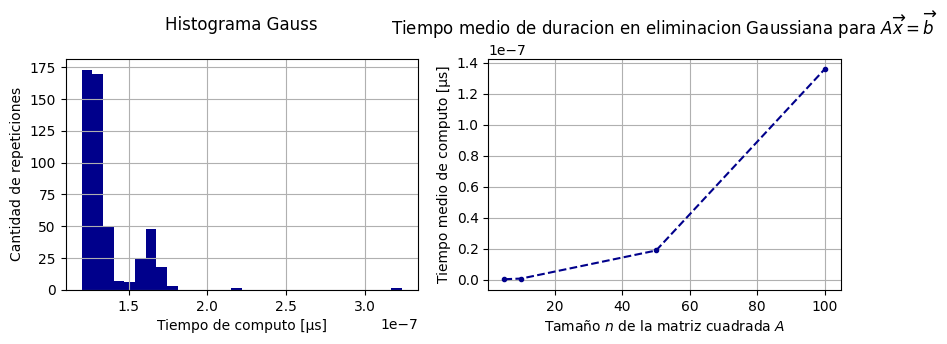

In [ ]:
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
# histograma
axes[0].set_title('Histograma Gauss\n')
axes[0].hist(Δt, bins=30,color='darkblue')
axes[0].set_ylabel('Cantidad de repeticiones')
axes[0].set_xlabel('Tiempo de computo [μs]')
axes[0].grid()
# grafica
axes[1].set_title('Tiempo medio de duracion en eliminacion Gaussiana para $A\overrightarrow{x}=\overrightarrow{b}$')
axes[1].plot(n,Δt_medio,'.--', color='darkblue')
axes[1].set_ylabel('Tiempo medio de computo [μs]')
axes[1].set_xlabel('Tamaño $n$ de la matriz cuadrada $A$')
axes[1].grid()

####**Discusión:**
<p align="justify"> La grafica obtenida para el tiempo de cómputo medio en función del tamaño n de la matriz, tiene en esencia la misma forma que la obtenida en el punto anterior. Lo cual se explicaría debido a que el número de operaciones está relacionado directamente con el tiempo de cómputo requerido, se podría de ver de forma intuitiva de este modo; si para $1$ operación se quiere un tiempo $t$, para $n$ operaciones se requeriría de un tiempo $n*t$.
Entonces el tiempo de cómputo y el número de operaciones está relacionado mediante un escalamiento.  

El histograma muestra una distribución con tendencia derecha de doble pico que posiblemente este explicada debido a la generación de números aleatorios de las entradas de la matriz por la función 'random.random()' </p>


<br>

## **3.** Tiempo medio de calculo para resolver el sistema por eliminacion **Gauss-Jordan**

In [ ]:
def GaussJordan(A): # Eliminacion Gauss-Jordan
    B=np.copy(A)
    m=len(B[:,0])  # Número filas
    n=len(B[0,:])  # Número columnas
    k=min([m,n])   # Para matrices que no son cuadradas
    # print('Original \n',B )
    for j in range(k):       # Corremos sobre las columnas
        for i in range(j,m): # Corremos sobre las filas
            if B[i,j]!=0:    # Encontramos el pivote
                break
        B = row_swap(B,i,j)
        # print(i,j,'Intercambio \n',B )
        if B[j,j]==0:      # Si no hay pivote pasar a la siguiente columna
            continue
        B = row_lamb(B,j,1/B[j,j])
        for i in range(m): # Corremos sobre TODAS las filas:
            if i==j:
                continue
            #print(i,j,'Combinación',-B[i,j],'/',B[j,j],'\n',B )
            B = row_comb(B,i,j,-B[i,j]/B[j,j])
    return B

def GaussJordan_Solve(A,b): # Solucion del sistema Ax=b por Gauss-Jordan
    G = GaussJordan(np.c_[A,b])
    x = G[:,-1]
    return x

In [ ]:
# Solucion a 500 sistemas Ax=b por Gauss-Jordan
Δt_2 = np.zeros(s)                   # arreglo de tiempos
Δt_medio_2 = np.zeros(len(n))        # arreglo de tiempo medio

for k in range(len(n)):    # para cada valor de n=[5,10,50,100]
  A = np.random.random((n[k],n[k]))   # matriz nxn
  b = np.random.random(n[k])          # vector nx1

  for i in tqdm(range(s)): # s=500 cantidad de sistemas
    start_2 = time.time()             # tiempo de inicio
    GaussJordan_Solve(A,b)            # solucion Gauss-Jordan
    end_2 = time.time()               # tiempo de fin
    Δt_2[i] = (end_2-start_2)*10**(-6)# tiempo para cada solucion [μs]

  Δt_medio_2[k] = np.mean(Δt_2)     # tiempo medio de solucion [μs]

100%|██████████| 500/500 [02:13<00:00,  3.73it/s]


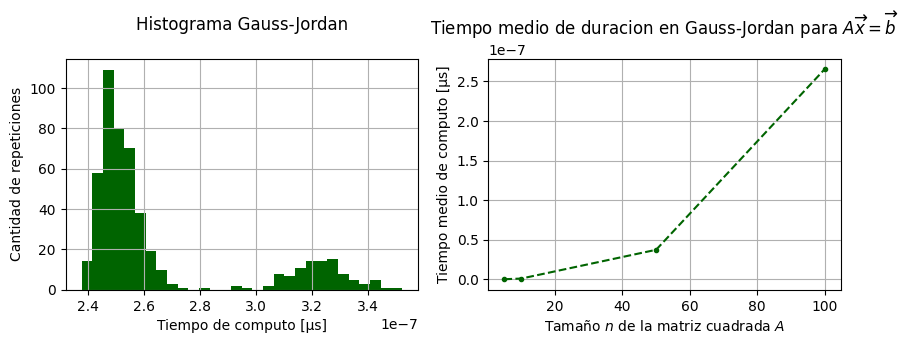

In [ ]:
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
# histograma
axes[0].set_title('Histograma Gauss-Jordan\n')
axes[0].hist(Δt_2, bins=30,color='darkgreen')
axes[0].set_ylabel('Cantidad de repeticiones')
axes[0].set_xlabel('Tiempo de computo [μs]')
axes[0].grid()
# grafica
axes[1].set_title('Tiempo medio de duracion en Gauss-Jordan para $A\overrightarrow{x}=\overrightarrow{b}$')
axes[1].plot(n, Δt_medio_2,'.--', color='darkgreen')
axes[1].set_ylabel('Tiempo medio de computo [μs]')
axes[1].set_xlabel('Tamaño $n$ de la matriz cuadrada $A$')
axes[1].grid()

In [ ]:
print('Tiempos medios Gauss:',Δt_medio)
print('Tiempos medios Gauss-Jordan:',Δt_medio_2)

Tiempos medios Gauss: [2.55543709e-10 6.87796116e-10 1.87983670e-08 1.35820145e-07]
Tiempos medios Gauss-Jordan: [3.35655212e-10 1.18028402e-09 3.74250250e-08 2.65115656e-07]


####**Discusión:**

<p align="justify"> Como se esperaba se puede observar que la mayoría de los tiempos medios de cómputo de solución por Gauss-Jordan son prácticamente el doble de los tiempos de cómputo por eliminación Gaussiana. De la función tqdm también se puede evidenciar esto, pues para los dos últimos valores de $n$ $(50$ y $100)$, en particular para $n=100$ el método de Gauss toma cerca de 1 minuto, mientras el método de Gauss-Jordan toma cerca de 2 minutos.</p>

<p align="justify"> Sin embargo, estrictamente no tienden a ser el doble, siendo más evidente para los primeros valores de $n$, $n=5$ y $n=10$, es decir que la segunda parte de Gauss-Jordan, el proceso de volver la matriz triangular superior en una matriz diagonal requiere de a lo sumo las mismas operaciones para volver a la matriz inicial A en triangular superior, o menos.</p>



<br>

## **4.** Cantidad de operaciones en determinante de matriz $3$x$3$

En general el determinante de una matriz A:
$$\det[A]=\sum_j a_{ij} C_{ij}$$
Particularmente para $A_{3x3}$, la  fila fija $i=1$ y con matriz de cofactores: $C_{ij}=(-1)^{i+j}M_{ij}$

$$\det[A_{3x3}]=\sum_j a_{ij} C_{ij}$$
$$= a_{11} C_{11} + a_{12} C_{12}+ a_{13} C_{33}$$

$$=a_{11} (-1)^{1+1}M_{11} + a_{12}
(-1)^{1+2}M_{12}+ a_{13} (-1)^{1+3}M_{13}$$

$$=a_{11} (-1)^{0}M_{11} + a_{12}
(-1)^{1}M_{12}+ a_{13} (-1)^{2}M_{13}$$

<br>

Teniendo en cuenta $M_{ij}$ es una matriz $2$x$2$, con determinante: $\det[A_{2x2}]=a_{11}a_{22}-a_{12}a_{21}$, este determinante tiene 2 productos y 1 suma: <br>(**$3$ operaciones**)

Note que hay 3 términos en el determinante $3$x$3$, cada uno con **2 productos** (el de la entrada con el signo, y con el determinante de $M_{ij}$)
<br>(**$2$ operaciones**)

**Entonces:** (3 operaciones del determinante M, + 2 productos por cada termino, y repetido 3 veces pues son 3 términos. además, como los 3 términos están sumados, existen 2 sumas)

> **$(3+2)*3 + 2 = 17$ Operaciones**

<br>
Note que si se cuenta las operaciones del signo, entonces el exponente $0$: aporta 0 productos, el $1$ aporta 0 productos, y el $2$ aporta 1 producto

> **$17+1=18$ Operaciones**

<br>
Por el contrario, si se toma al signo simplemente como la misma adición, se tienen:

> **$(3+1)*3 + 2 = 14$ Operaciones**


In [ ]:
def Det(A):  # Determinante de una matriz
    B=np.copy(A)
    B=B.astype('float64')
    n=len(B)
    if n==1: return B[0,0]
    krow = np.delete(range(n),0)
    det=  0
    for j in range(n):
        kcol = np.delete(range(n),j)
        M = B[krow,:][:,kcol]

        det += B[0,j]*((-1)**j)*Det(M)
    return det

In [ ]:
import sympy as sp
from sympy import count_ops

def Det_op_3x3(A): # Modificacion para conteo de operaciones determinante 3x3
    B = np.copy(A)
    B = B.astype('float64')
    n = len(B)
    if n==1: return B[0,0]
    krow = np.delete(range(n),0)
    det=  0; num_ops = 0 # inicializando determinte y # de operaciones

    for j in range(n):
        kcol = np.delete(range(n),j)
        M = B[krow,:][:,kcol]

        B_0j = sp.symbols('B_0J') # entrada
        j = sp.symbols('j')       # exponente del signo
        a = sp.symbols('a'); b =sp.symbols('b'); c =sp.symbols('c'); d =sp.symbols('d')
        DetM = a*d-c*b            # determinante 2x2

        det += B_0j*(-1)**j*DetM  # determinante 3x3
        num_ops += count_ops(det) # conteo de operaciones

    return print('El determinante 3x3 tiene:', num_ops, 'operaciones')

A = np.array([[1, 2, 1],[2, 4, 3],[3, 3, 1]])
Det_op_3x3(A)

El determinante 3x3 tiene: 23 operaciones


Son más operaciones que las supuestas anteriormente pues el método `count_ops`, toma en cuenta como operación también el signo $(-)$ y el exponente, de modo que la maquina está tomando: ($3$ op del det2x2, $2$ op de los productos de cada término del det3x3, $1$ op del signo y $1$ op del exponente) esto repetido 3 veces más las dos sumas resulta: (op: operación)

> **$(3+2+1+1)*3 + 2 = 23$ Operaciones**

En general este número de operaciones depende de que se quiera tomar  específicamente como operación, y de como esté definida la función o método de conteo en el programa, en este caso se tomó una función `count_ops` de `sympy` que hace uso de variables simbólicas, no obstante pueden existir diferentes métodos.


In [ ]:
#Tarea 5 90/100

#1. Número medio de operaciones 10/10

#2. Histogramas Gauss 30/30
#n=5 5/5
#n=10 5/5
#n=50 10/10
#n=100 10/10

#3. Histogramas GaussJordan 30/30
#n=5 5/5
#n=10 5/5
#n=50 10/10
#n=100 10/10

#4. Contador Determinante 20/30
#Solución Operaciones: 14
#Muy confusa tu explicación y estimas mal el número de operaciones expandiendo el determinante.
